In [236]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates

# Встановлюємо стиль для всіх графіків
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Налаштування для відображення кирилиці
plt.rcParams['font.family'] = 'DejaVu Sans'

# Шлях до файлу
file_path = "homelessanimals.csv"

# Відкриття CSV-файлу
df = pd.read_csv(file_path, sep=';', parse_dates=['captureDate'], memory_map=True, encoding='utf-8')

In [238]:
# Перегляд перших кількох рядків
df.head()

,chipUid,catchName,catchId,captureDate,captureCATUTTC,captureAddressPostCode,captureAddressAdminUnitL1,captureAddressAdminUnitL2,captureAddressAdminUnitL3,captureAddressAdminUnitL4,...,releasedAddressAdminUnitL2,releasedAddressAdminUnitL3,releasedAddressAdminUnitL4,releasedAddressPostName,releasedAddressThoroughfare,releasedAddressLocatorDesignator,releasedAddressLocatorBuilding,releasedAddressDescription,releasedLat,releasedLon
0,2337,"КП ""Полігон ТПВ""",3364590,01.08.2024,UA26040190000081578,76008,Україна,Івано-Франківська обл,Франківський,Івано-Франківська,...,Івано-Франківська,Івано-Франківський,Івано-Франківська,Івано-Франківськ,вул. Федьковича,NaN,NaN,NaN,NaN,NaN
1,2332,"КП ""Полігон ТПВ""",3364590,09.01.2024,UA26040190000081578,76018,Україна,Івано-Франківська обл,Франківський,Івано-Франківська,...,Івано-Франківська,Івано-Франківський,Івано-Франківська,Івано-Франківськ,вул.Мельника,NaN,NaN,NaN,NaN,NaN
2,2331,"КП ""Полігон ТПВ""",3364590,09.01.2024,UA26040190000081578,76018,Україна,Івано-Франківська обл,Франківський,Івано-Франківська,...,Івано-Франківська,Івано-Франківський,Івано-Франківська,Івано-Франківськ,вул.Мельника,NaN,NaN,NaN,NaN,NaN
3,2330,"КП ""Полігон ТПВ""",3364590,09.01.2024,UA26040190000081578,77457,Україна,Івано-Франківська обл,Франківський,Івано-Франківська,...,Івано-Франківська,Івано-Франківський,Івано-Франківська,с.Радча,NaN,NaN,NaN,NaN,NaN,NaN
4,2333,"КП ""Полігон ТПВ""",3364590,09.01.2024,UA26040190000081578,76494,Україна,Івано-Франківська обл,Франківський,Івано-Франківська,...,Івано-Франківська,Івано-Франківський,Івано-Франківська,Івано-Франківськ,вул.Юності,NaN,NaN,NaN,NaN,NaN


In [240]:
# Огляд структури даних
print("\nІнформація про датасет:")
print(df.info())


Інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 43 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   chipUid                           171 non-null    int64  
 1   catchName                         171 non-null    object 
 2   catchId                           171 non-null    int64  
 3   captureDate                       171 non-null    object 
 4   captureCATUTTC                    171 non-null    object 
 5   captureAddressPostCode            171 non-null    int64  
 6   captureAddressAdminUnitL1         171 non-null    object 
 7   captureAddressAdminUnitL2         171 non-null    object 
 8   captureAddressAdminUnitL3         171 non-null    object 
 9   captureAddressAdminUnitL4         171 non-null    object 
 10  captureAddressPostName            167 non-null    object 
 11  captureAddressThoroughfare        137 non-null

In [242]:
# Перевірка пропущених значень
missing_values = df.isnull().sum()
print("\nПропущені значення:\n", missing_values[missing_values > 0])


Пропущені значення:
 captureAddressPostName                4
captureAddressThoroughfare           34
captureAddressLocatorDesignator     126
captureAddressLocatorBuilding       171
captureAddressDescription           171
captureLat                          142
captureLon                          142
animalBreed                         171
animalAge                             7
animalFur                           141
animalHeight                        141
animalWeight                        141
vaccinationsInfo                    171
releasedDate                         20
releaseCATUTTC                        1
releasedAddressAdminUnitL3            1
releasedAddressPostName               4
releasedAddressThoroughfare          39
releasedAddressLocatorDesignator    135
releasedAddressLocatorBuilding      171
releasedAddressDescription          171
releasedLat                         141
releasedLon                         141
dtype: int64


In [244]:
# Видаляємо надлишкові колонки
columns_to_drop = [
    'captureAddressAdminUnitL1', 'captureAddressAdminUnitL2', 'captureAddressAdminUnitL3', 'captureAddressAdminUnitL4',
    'releasedAddressAdminUnitL1', 'releasedAddressAdminUnitL2', 'releasedAddressAdminUnitL3', 'releasedAddressAdminUnitL4',
    'catchName', 'catchId', 'veterinary Name', 'veterinary Id', 'captureCATUTTC', 'releaseCATUTTC'
]
df_cleaned = df.drop(columns=columns_to_drop)

# Обробка пропущених значень
df_cleaned['animalAge'] = df_cleaned['animalAge'].fillna('Невідомо')
df_cleaned['animalColor'] = df_cleaned['animalColor'].fillna('Невідомо')
df_cleaned['releasedDate'] = df_cleaned['releasedDate'].fillna('Ще не випущено')

# Конвертація дат у формат datetime
df_cleaned['captureDate'] = pd.to_datetime(df_cleaned['captureDate'], format='%d.%m.%Y', errors='coerce')
df_cleaned['releasedDate'] = pd.to_datetime(df_cleaned['releasedDate'], format='%d.%m.%Y', errors='coerce')

# Переглядаємо очищені дані
print("Очищений датасет:")
print(df_cleaned.info())

Очищений датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   chipUid                           171 non-null    int64         
 1   captureDate                       166 non-null    datetime64[ns]
 2   captureAddressPostCode            171 non-null    int64         
 3   captureAddressPostName            167 non-null    object        
 4   captureAddressThoroughfare        137 non-null    object        
 5   captureAddressLocatorDesignator   45 non-null     object        
 6   captureAddressLocatorBuilding     0 non-null      float64       
 7   captureAddressDescription         0 non-null      float64       
 8   captureLat                        29 non-null     float64       
 9   captureLon                        29 non-null     float64       
 10  animalSpecies                   

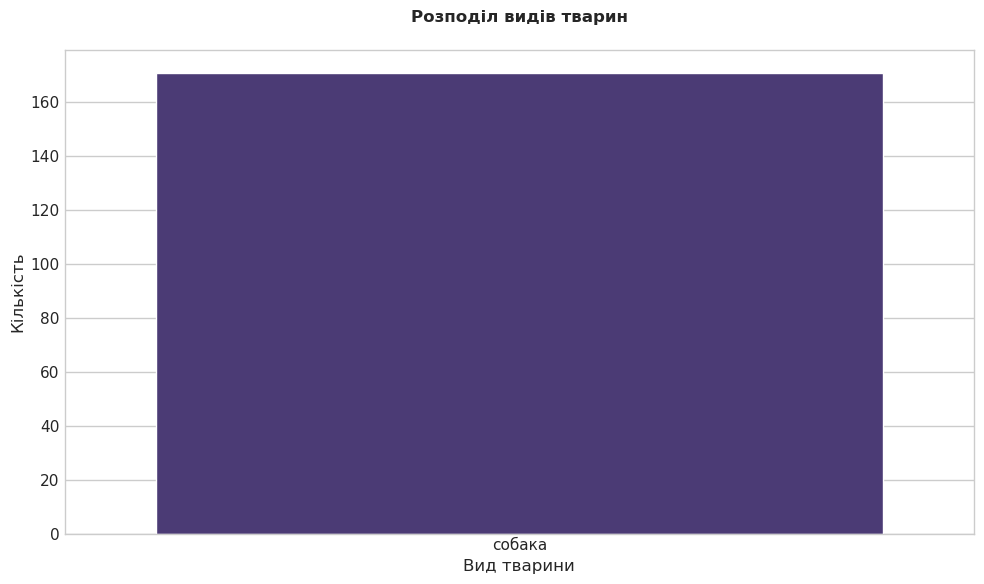

In [246]:
plt.figure(figsize=(10, 6))
sns.countplot(x='animalSpecies', data=df_cleaned, order=df_cleaned['animalSpecies'].value_counts().index)
plt.title('Розподіл видів тварин', fontweight='bold', pad=20)
plt.xlabel('Вид тварини', fontsize=12)
plt.ylabel('Кількість', fontsize=12)
plt.tight_layout()
plt.show()

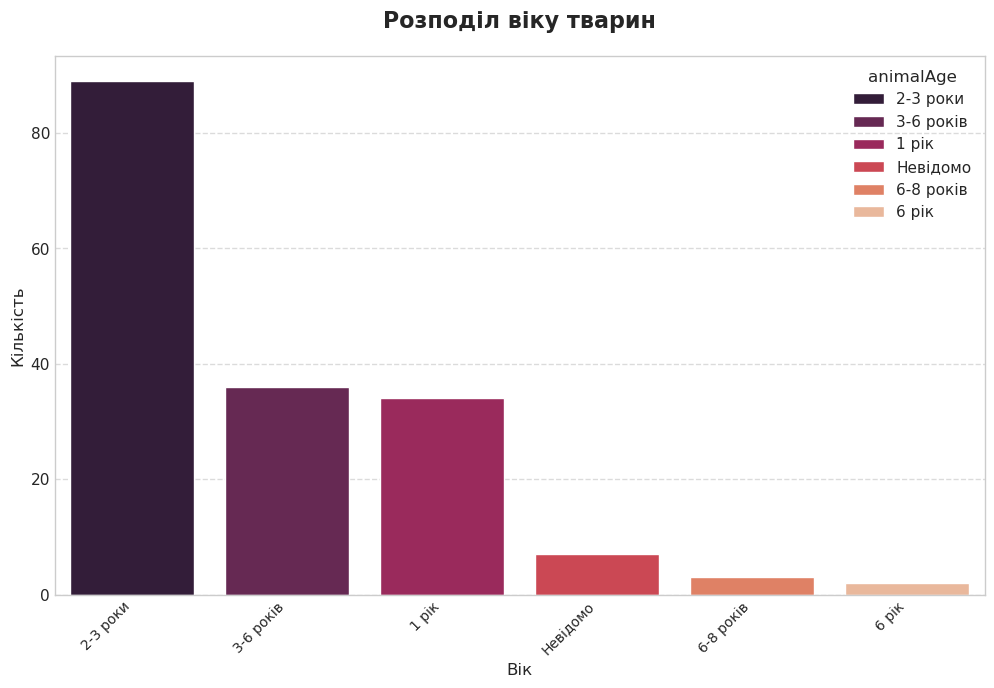

In [248]:
# Розподіл віку тварин
plt.figure(figsize=(12, 7))
order = df_cleaned['animalAge'].value_counts().index
ax2 = sns.countplot(x='animalAge', data=df_cleaned, order=order, palette='rocket', legend=True, hue='animalAge')
plt.title('Розподіл віку тварин', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Вік', fontsize=12)
plt.ylabel('Кількість', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

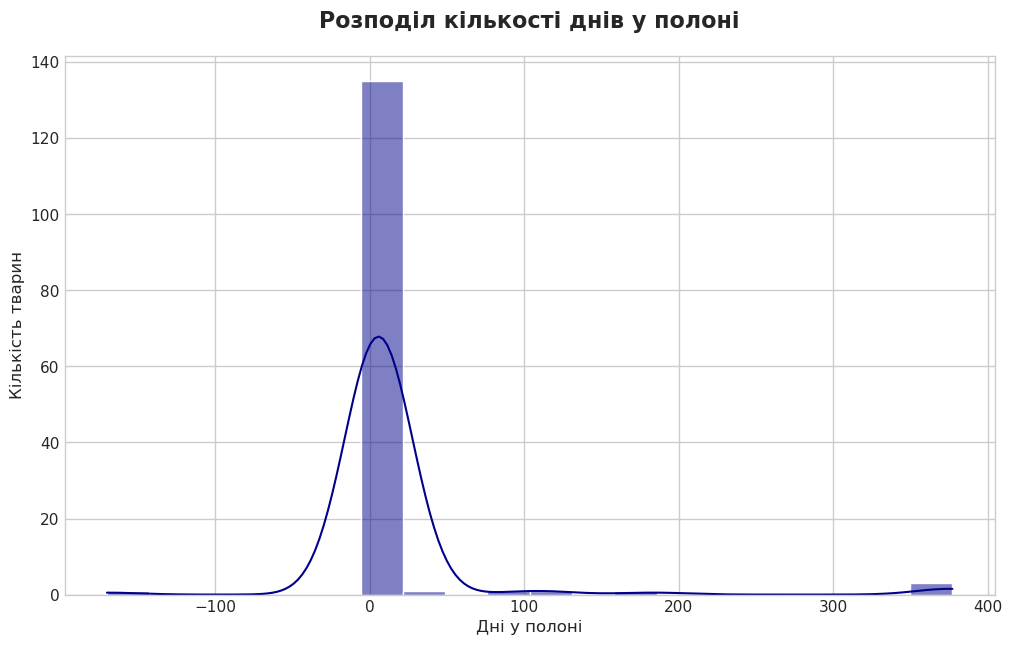

In [250]:
# Додаємо колонку "днів у полоні"
df_cleaned['days_in_captivity'] = (df_cleaned['releasedDate'] - df_cleaned['captureDate']).dt.days

plt.figure(figsize=(12, 7))
ax3 = sns.histplot(df_cleaned['days_in_captivity'].dropna(), bins=20, kde=True, color='darkblue')
plt.title('Розподіл кількості днів у полоні', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Дні у полоні', fontsize=12)
plt.ylabel('Кількість тварин', fontsize=12)
plt.show()

In [252]:
# Витягуємо рік і місяць із дати захоплення
df_cleaned['captureYear'] = df_cleaned['captureDate'].dt.year
df_cleaned['captureMonth'] = df_cleaned['captureDate'].dt.month

# Кодування статі (1 — самець, 2 — самиця)
df_cleaned['animalSex'] = df_cleaned['animalSex'].map({1: 'Самець', 2: 'Самиця'})

# Переглядаємо нові колонки
print(df_cleaned[['captureDate', 'captureYear', 'captureMonth', 'animalSex']].head())

  captureDate  captureYear  captureMonth animalSex
0  2024-08-01       2024.0           8.0    Самиця
1  2024-01-09       2024.0           1.0    Самиця
2  2024-01-09       2024.0           1.0    Самець
3  2024-01-09       2024.0           1.0    Самиця
4  2024-01-09       2024.0           1.0    Самиця


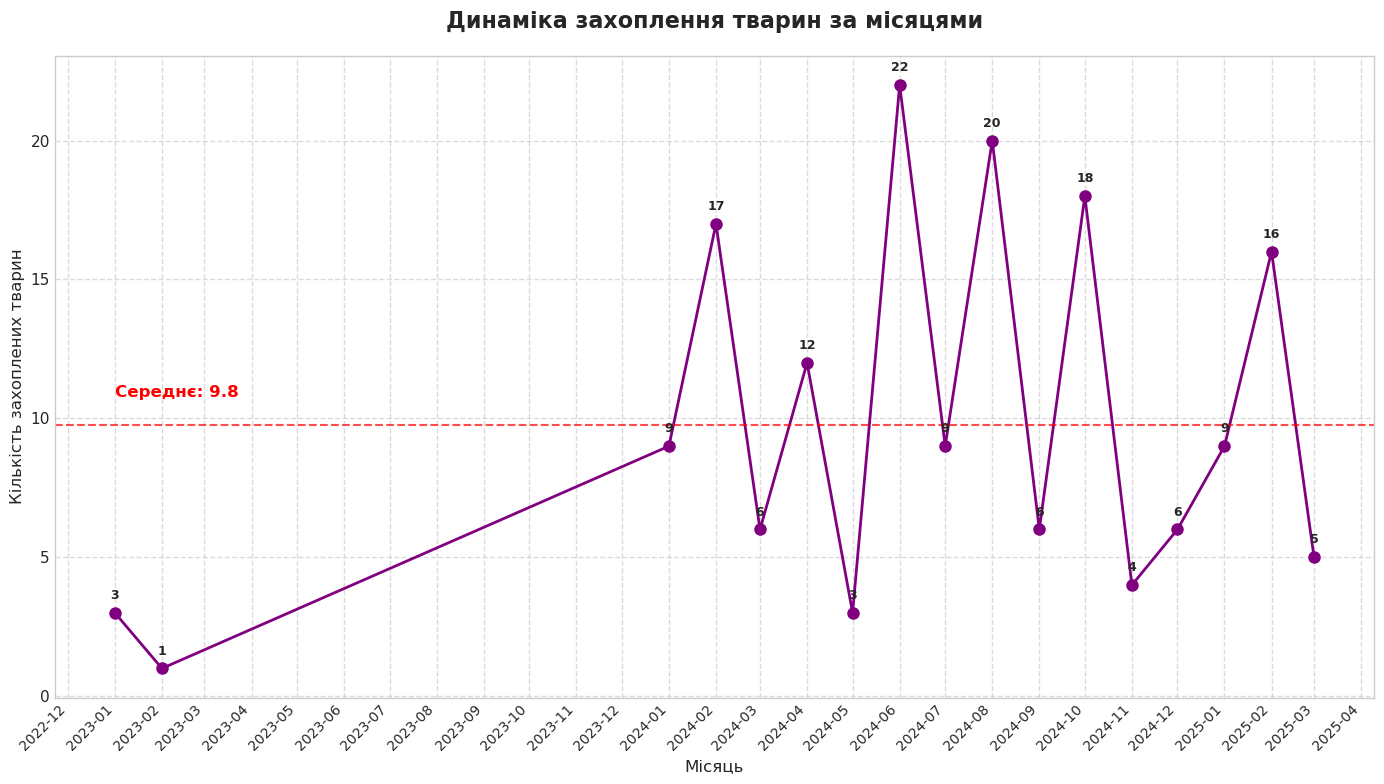

In [254]:
# Кількість захоплень за місяць
plt.figure(figsize=(14, 8))
monthly_captures = df_cleaned.groupby(df_cleaned['captureDate'].dt.to_period('M')).size()
monthly_captures.index = monthly_captures.index.to_timestamp()

ax5 = monthly_captures.plot(marker='o', linestyle='-', linewidth=2, markersize=8, color='purple')
plt.title('Динаміка захоплення тварин за місяцями', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Місяць', fontsize=12)
plt.ylabel('Кількість захоплених тварин', fontsize=12)

# Форматуємо вісь X для кращого відображення дат
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax5.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45, ha='right', fontsize=10)

# Додаємо значення над точками
for x, y in zip(monthly_captures.index, monthly_captures.values):
    plt.annotate(f'{y}', (x, y), textcoords="offset points", 
                xytext=(0,10), ha='center', fontweight='bold', fontsize=9)

# Додаємо горизонтальну лінію з середнім значенням
avg_captures = monthly_captures.mean()
plt.axhline(y=avg_captures, color='red', linestyle='--', alpha=0.7)
plt.text(monthly_captures.index[0], avg_captures + 1, 
         f'Середнє: {avg_captures:.1f}', color='red', fontweight='bold')

# Додаємо сітку та покращуємо вигляд
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

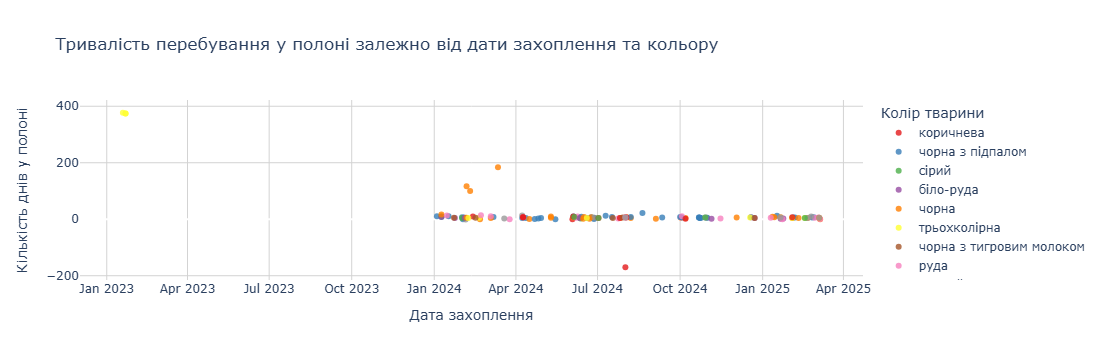

In [255]:
import plotly.express as px

fig = px.scatter(
    df_cleaned,
    x="captureDate",
    y="days_in_captivity",
    color="animalColor",
    title="Тривалість перебування у полоні залежно від дати захоплення та кольору",
    labels={"captureDate": "Дата захоплення", "days_in_captivity": "Днів у полоні", "animalColor": "Колір тварини"},
    color_discrete_sequence=px.colors.qualitative.Set1,  
    opacity=0.8,
    size_max=10,
    hover_data=["animalSpecies", "animalBreed", "captureAddressPostName"]
)


fig.update_layout(
    xaxis_title="Дата захоплення",
    yaxis_title="Кількість днів у полоні",
    plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="lightgrey"),
    yaxis=dict(showgrid=True, gridcolor="lightgrey"),
)

fig.show()

In [257]:
# Збереження у CSV-файл
df_cleaned.to_csv('cleaned_dataset.csv', sep=';', encoding='utf-8', index=False)

print("Очищений датасет збережено у 'cleaned_dataset.csv'")

Очищений датасет збережено у 'cleaned_dataset.csv'
